In [10]:
# import sys
import importlib as im

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

from pathlib import Path

import h5py


In [32]:
def getWhizzData(whizzFile, line, channel):
    """
    Returns a numpy array containg the specified channel of
    data for the given line.

    Parameters
    ----------
    whizzFile : String or pathlib.PosixPath
        Name of a HDF5 Whizz file, including path and extension.
    line : String
        A flightline, e.g. '1000110.0'.
    channel : String
        The (case-sensitive) name of a channel in the database, e.g. 'EASTING'.

    Returns
    -------
    my_data : numpy array
        The requested data.

    """
    filename = str(whizzFile)

    with h5py.File(filename, 'r') as f:
        g = f[groupName]['Lines']
        my_data = getLineData(g[line], channel)
            
    return my_data


def getLineData(linegroup, channel):
    """
    Returns a numpy array containg the specified channel of
    data for the given line.

    Parameters
    ----------
    line : HDF5 Group
        A flight-line group.
    channel : String
        The (case-sensitive) name of a channel in the database, e.g. 'EASTING'.

    Returns
    -------
    my_data : numpy array
        The requested data.

    """

    for datachannel in linegroup.items():
      if datachannel[0].upper() == channel.upper():
          my_data = np.array(linegroup[datachannel[0]])
            
    return my_data

In [4]:
data_root = "/Users/markdransfield/Documents/GitHub/AirGravQC/examples/"
dx = Path(data_root + r'AirFTG/VintonDome.xyz')
dh = dx.with_suffix('.hdf5')

In [8]:
channels = ['Altitude', 'Cross1_raw', 'Cross2_raw', 'Cross3_raw', 'Drape', 'HHMMSS', 
            'Inline1_raw', 'Inline2_raw', 'Inline3_raw', 'Lat', 'Lon', 'TC_Txx_100', 
            'TC_Txz_100', 'TC_Tyx_100', 'TC_Tyy_100', 'TC_Tyz_100', 'TC_Tzz_100', 
            'Terrain', 'Time', 'Txx_slv', 'Txz_slv', 'Tyx_slv', 'Tyy_slv', 'Tyz_slv', 
            'Tzz_slv', 'X', 'Y', 'YYMMDD']

In [7]:
lines = ['10.000', '100.000', '11.0', '110.000', '111.000', '120.000', '130.000', '131.000', 
         '131.100', '140.000', '150.000', '151.000', '151.100', '151.200', '160.000', '170.000', 
         '171.000', '191.000', '20.000', '211.000', '211.100', '231.000', '251.000', '271.000', 
         '271.100', '291.000', '291.100', '30.000', '31.000', '31.100', '311.000', '331.000', 
         '351.000', '371.000', '371.100', '391.000', '40.000', '401.000', '411.000', '411.100', 
         '421.000', '431.000', '431.100', '441.000', '451.000', '461.000', '461.100', '471.000', 
         '481.000', '491.000', '50.000', '501.000', '501.100', '51.000', '51.100', '511.000',
         '521.000', '531.000', '541.000', '541.100', '541.200', '551.000', '561.000', '581.000', 
         '60.000', '601.000', '601.100', '621.000', '641.000', '641.100', '661.000', '661.100', 
         '681.000', '70.000', '701.000', '71.000', '721.000', '741.000', '741.100', '761.000', 
         '761.100', '781.000', '80.000', '801.000', '821.000', '841.000', '841.100', '861.000', 
         '881.000', '90.000', '91.000']

In [12]:
groupName = 'Whizz Version 1.0'

In [33]:
t = getWhizzData(dh, lines[0], 'time')

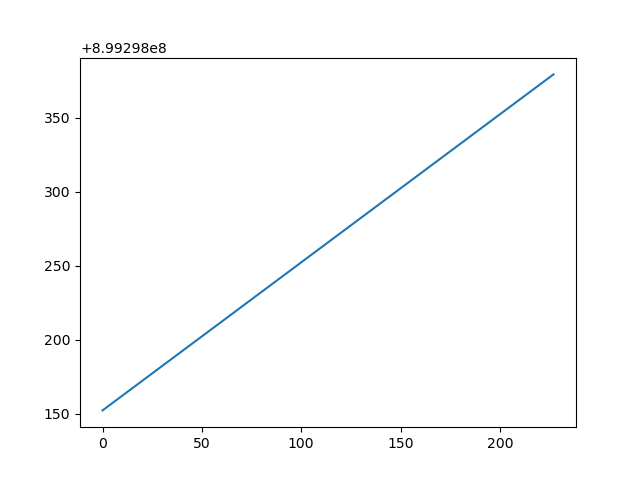

In [35]:
plt.plot(t)

In [29]:
t[0].upper()

'YYMMDD'